### Basic setup

In [1]:
# Here I set up the environment so I can import my src package

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = r"C:\Users\Arafat\Desktop\IMA Project"
if project_root not in sys.path:
    sys.path.append(project_root)

from src import config
from src import data_loading
from src import visualization
from src.utils import set_random_seed

# I just make sure folders exist and random seed is fixed
config.make_all_dirs()
set_random_seed(42)

# for ploting plots
sns.set(style="whitegrid")


[utils] Random seed set to 42


### check data and raw structure

In [2]:
# Here I want to check that Kaggle dataset is correctly placed under data/raw

print("RAW_DATA_DIR:", config.RAW_DATA_DIR)
print("Content of RAW_DATA_DIR:", os.listdir(config.RAW_DATA_DIR))

if "TRAIN" in os.listdir(config.RAW_DATA_DIR):
    print("TRAIN folder is found")
else:
    print("TRAIN folder not found.")


RAW_DATA_DIR: C:\Users\Arafat\Desktop\IMA Project\data\raw
Content of RAW_DATA_DIR: ['TEST', 'TRAIN']
Looks like TRAIN folder is found :)


### scan all images and create DataFrame

In [3]:
# Here I scan all images under data/raw and build a DataFrame with filepath + label
# label will be the immediate parent folder (EOSINOPHIL, LYMPHOCYTE etc.)

image_root_dir = config.RAW_DATA_DIR
print("Using image root dir:", image_root_dir)

df_all = data_loading.scan_image_folder_to_df(image_root_dir)
print("First few rows of df_all:")
df_all.head()


Using image root dir: C:\Users\Arafat\Desktop\IMA Project\data\raw
[data_loading] Found 12444 images in C:\Users\Arafat\Desktop\IMA Project\data\raw
[data_loading] Label value counts:
label
NEUTROPHIL    3123
EOSINOPHIL    3120
LYMPHOCYTE    3103
MONOCYTE      3098
Name: count, dtype: int64
First few rows of df_all:


,filepath,label
0,C:\Users\Arafat\Desktop\IMA Project\data\raw\T...,EOSINOPHIL
1,C:\Users\Arafat\Desktop\IMA Project\data\raw\T...,EOSINOPHIL
2,C:\Users\Arafat\Desktop\IMA Project\data\raw\T...,EOSINOPHIL
3,C:\Users\Arafat\Desktop\IMA Project\data\raw\T...,EOSINOPHIL
4,C:\Users\Arafat\Desktop\IMA Project\data\raw\T...,EOSINOPHIL


### basic statistics

Total number of images: 12444

Class counts:
label
NEUTROPHIL    3123
EOSINOPHIL    3120
LYMPHOCYTE    3103
MONOCYTE      3098
Name: count, dtype: int64


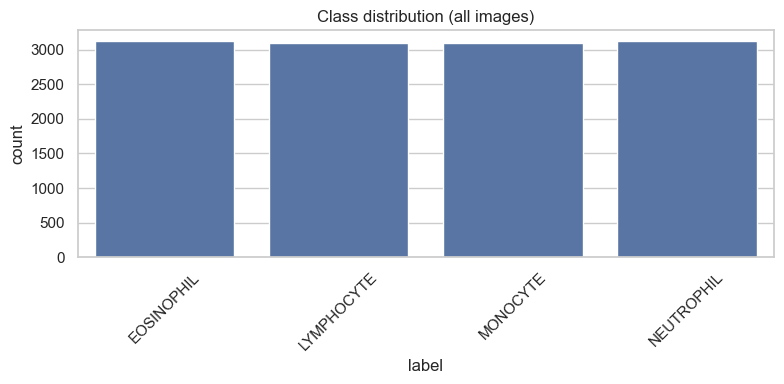

In [4]:
print("Total number of images:", len(df_all))
print("\nClass counts:")
print(df_all["label"].value_counts())

visualization.plot_class_distribution(df_all, label_column="label", title="Class distribution (all images)")


### create train/val/test split

In [5]:
# Here I create my own train/val/test split from all images
# I choose 20% test, 20% val, the rest train

df_splits = data_loading.create_train_val_test_split(
    df_all,
    test_size=0.2,
    val_size=0.2,
    random_seed=42,
)

# I save this to CSV so I can reuse it later in other notebooks
split_csv_path = data_loading.save_splits_to_csv(df_splits)
print("Split CSV saved at:", split_csv_path)

df_splits.head()


[utils] Random seed set to 42
[data_loading] Split sizes:
split
train    7466
val      2489
test     2489
Name: count, dtype: int64
[data_loading] Split info saved to C:\Users\Arafat\Desktop\IMA Project\data\processed\splits\split_info.csv
Split CSV saved at: C:\Users\Arafat\Desktop\IMA Project\data\processed\splits\split_info.csv


,filepath,label,split
0,C:\Users\Arafat\Desktop\IMA Project\data\raw\T...,NEUTROPHIL,train
1,C:\Users\Arafat\Desktop\IMA Project\data\raw\T...,MONOCYTE,train
2,C:\Users\Arafat\Desktop\IMA Project\data\raw\T...,LYMPHOCYTE,train
3,C:\Users\Arafat\Desktop\IMA Project\data\raw\T...,EOSINOPHIL,train
4,C:\Users\Arafat\Desktop\IMA Project\data\raw\T...,EOSINOPHIL,train


### inspect sizes of each split

In [6]:
print("Split counts:")
print(df_splits["split"].value_counts())

print("\nClass distribution per split:")
print(df_splits.groupby("split")["label"].value_counts())


Split counts:
split
train    7466
val      2489
test     2489
Name: count, dtype: int64

Class distribution per split:
split  label     
test   NEUTROPHIL     625
       EOSINOPHIL     624
       LYMPHOCYTE     621
       MONOCYTE       619
train  NEUTROPHIL    1873
       EOSINOPHIL    1872
       LYMPHOCYTE    1862
       MONOCYTE      1859
val    NEUTROPHIL     625
       EOSINOPHIL     624
       LYMPHOCYTE     620
       MONOCYTE       620
Name: count, dtype: int64


### show sample images per class

Labels found: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']


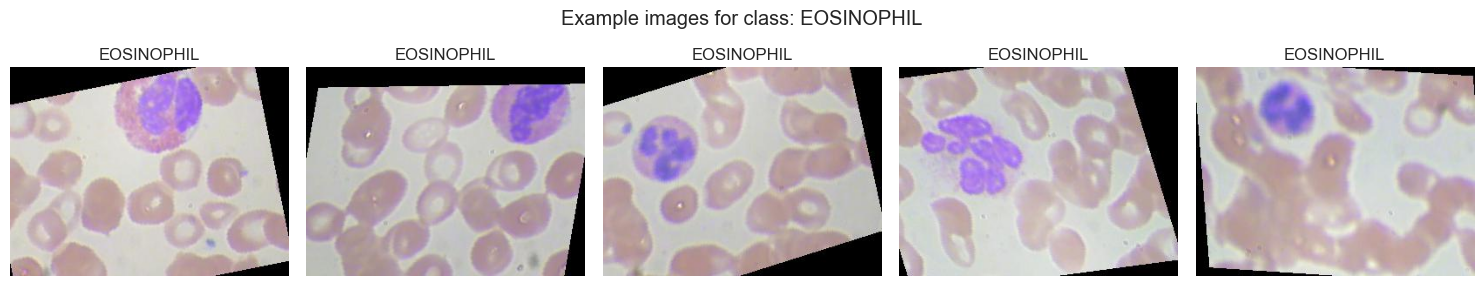

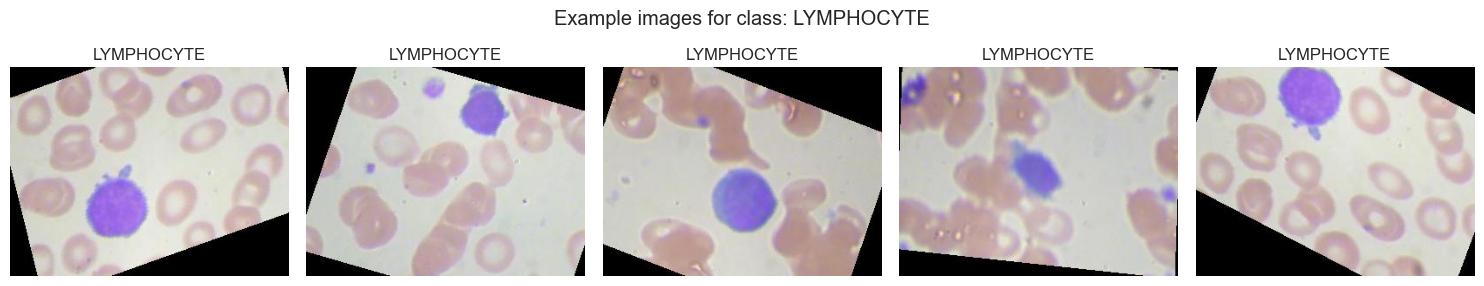

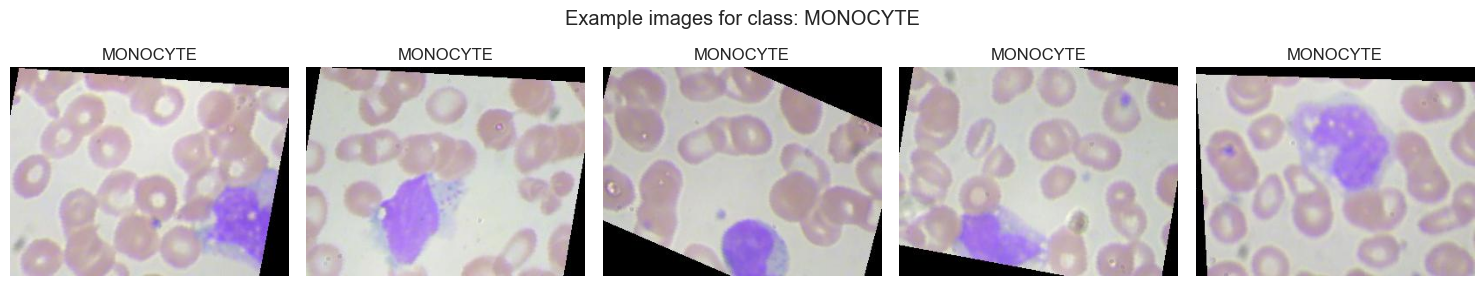

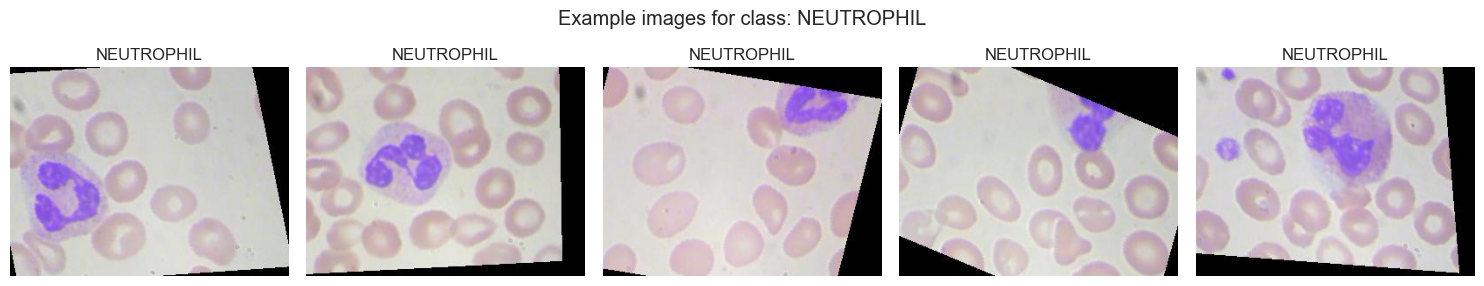

In [7]:
# Here I want to visualize a few samples from each class
# so I can see how they look

unique_labels = sorted(df_splits["label"].unique())
print("Labels found:", unique_labels)

for lab in unique_labels:
    temp_df = df_splits[df_splits["label"] == lab].sample(n=5, random_state=42)
    temp_paths = temp_df["filepath"].tolist()
    temp_labels = temp_df["label"].tolist()
    visualization.show_sample_images(temp_paths, temp_labels, num_cols=5, fig_title=f"Example images for class: {lab}")


### inspect original image sizes

Some sample heights: [240, 240, 240, 240, 240, 240, 240, 240, 240, 240]
Some sample widths: [320, 320, 320, 320, 320, 320, 320, 320, 320, 320]


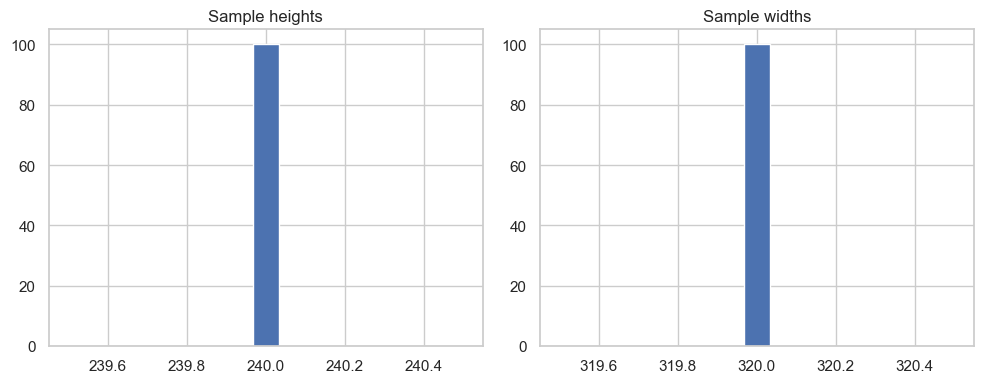

In [8]:
# Here I check what kind of sizes the original images have,
# just for my EDA. I don't need all, I just take 100 randomly.

from skimage import io

temp_df_sample = df_splits.sample(n=100, random_state=42)
height_list = []
width_list = []

for idx, row in temp_df_sample.iterrows():
    temp_img = io.imread(row["filepath"])
    height_list.append(temp_img.shape[0])
    width_list.append(temp_img.shape[1])

print("Some sample heights:", height_list[:10])
print("Some sample widths:", width_list[:10])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(height_list, bins=15)
plt.title("Sample heights")
plt.subplot(1,2,2)
plt.hist(width_list, bins=15)
plt.title("Sample widths")
plt.tight_layout()
plt.show()


### pixel intensity histograms

Total number of pixels sampled: 1536000


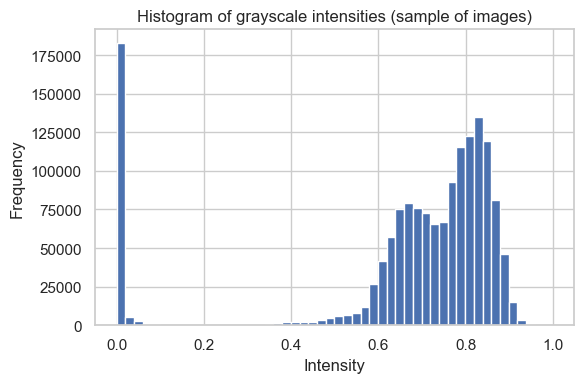

In [9]:
# Here I look at grayscale intensity distribution for a few random images

from skimage.color import rgb2gray
from skimage import img_as_float

temp_df_small = df_splits.sample(n=20, random_state=42)

all_pixels = []

for idx, row in temp_df_small.iterrows():
    temp_img = io.imread(row["filepath"])
    temp_img = img_as_float(temp_img)
    if temp_img.ndim == 3:
        temp_gray = rgb2gray(temp_img)
    else:
        temp_gray = temp_img
    all_pixels.append(temp_gray.ravel())

all_pixels = np.concatenate(all_pixels)
print("Total number of pixels sampled:", all_pixels.shape[0])

plt.figure(figsize=(6,4))
plt.hist(all_pixels, bins=50)
plt.title("Histogram of grayscale intensities (sample of images)")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
